In [1]:
# ── Cell 1a: Install dependency ────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install ucimlrepo --quiet

---
# Credit Default Risk Detection
## Mitigating Capital Loss via Ensemble and Semi-Supervised Architectures
### Predictive Analytics Individual Coursework Submission

---

## 1. Introduction & Business Problem

### 1.1 The Retail Banking Context
The fundamental objective of this project is to develop a machine learning pipeline capable of predicting retail credit card defaults in the subsequent billing cycle. In the context of consumer credit, the financial implications of misclassification are highly asymmetric:

1. **False Negative (Missed Default):** Approving a credit facility for a client who subsequently defaults results in direct capital loss and required write-offs.
2. **False Positive (False Alarm):** Denying a solvent client incurs an opportunity cost of lost interest revenue and generates customer friction. 

This pipeline is explicitly optimized to minimize the organization's financial exposure to high-risk accounts. Because of the asymmetric costs, standard accuracy is an invalid evaluation metric. The architecture is optimized for Recall and the F1-score to prioritize the capture of true defaults.

### 1.2 Dataset
The primary data source is the UCI Default of Credit Card Clients dataset. It consists of 30,000 observations of Taiwanese credit card holders, encompassing 23 independent variables representing demographic profiles, assigned credit limits, and historical payment data over a six-month rolling window.

### 1.3 Problem Taxonomy

| Dimension | Specification |
|---|---|
| Task Type | Binary Classification and Semi-Supervised Anomaly Detection |
| Input | 23 continuous and categorical financial features |
| Output | $\hat{y} \in \{0,1\}$ (0 = Solvent, 1 = Default) |
| Primary Metric | Recall, F1-Score, and False Negative Minimization |
| Validation | Stratified 80/20 holdout with pipeline-isolated synthetic oversampling |

## Data Acquisition and Problem Framing
**Objective:** Programmatically fetch the UCI Default of Credit Card Clients dataset and establish the predictive target.
* **Target Variable:** `default.payment.next.month` (Binary: 0 = Solvent, 1 = Default)
* **Rationale:** Utilizing the `ucimlrepo` API ensures strict environmental reproducibility, eliminating the need for local CSV file dependencies. 
* **Agent Verification:** An AI agent generated the initial fetch script. The output was manually audited against the official UCI schema to confirm dimensional integrity (30,000 observations, 23 independent features).

In [20]:
# ── Cell 1: Data Ingestion ─────────────────────────────────────────────────────
# Install the package if running in a fresh environment
# !pip install ucimlrepo --quiet

from ucimlrepo import fetch_ucirepo
import pandas as pd

# ── 1. Fetch dataset ───────────────────────────────────────────────────────────
# Dataset: Default of Credit Card Clients | UCI ID: 350
credit = fetch_ucirepo(id=350)

# ── 2. Separate features and target ───────────────────────────────────────────
X = credit.data.features          # pd.DataFrame  — 23 input features
y = credit.data.targets.squeeze() # pd.Series     — binary: 1=default, 0=no default

# Rename target column for clarity
y.name = "default.payment.next.month"

# ── 3. Sanity checks ──────────────────────────────────────────────────────────
print("=" * 60)
print(f"X shape : {X.shape}   ← (rows, features)")
print(f"y shape : {y.shape}   ← (rows,)")
print(f"Class balance:\n{y.value_counts(normalize=True).rename({0:'No Default', 1:'Default'}).to_string()}")
print("=" * 60)

print("\n── X.head() ──")
display(X.head())           # use print(X.head()) if not in Jupyter

print("\n── y.head() ──")
display(y.head())

print("\n── X.info() ──")
X.info()

X shape : (30000, 23)   ← (rows, features)
y shape : (30000,)   ← (rows,)
Class balance:
default.payment.next.month
No Default    0.7788
Default       0.2212

── X.head() ──


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



── y.head() ──


0    1
1    1
2    0
3    0
4    0
Name: default.payment.next.month, dtype: int64


── X.info() ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64


---
## 2. Exploratory Data Analysis & Verification

### 2.1 Target Class Imbalance
Initial inspection of the target variable `default.payment.next.month` revealed a severe class imbalance. The default class constitutes approximately 22 percent of the 30,000 observations. Without remediation, a gradient-based or tree-based classifier will inherently bias toward the profitable majority class, yielding high nominal accuracy but failing entirely as a risk management tool.

### 2.2 Feature Multicollinearity
Analysis of the continuous financial features (specifically `BILL_AMT1` through `BILL_AMT6`) demonstrated extreme positive Pearson correlation coefficients. This multicollinearity destabilizes coefficient estimates in standard linear models, providing direct empirical justification for the use of Random Forest ensembles and Neural Networks, which are robust to highly correlated input spaces.

### 2.3 Categorical Vocabulary Gap & Remediation
Cross-referencing the dataset with the official UCI data dictionary exposed hidden data quality issues. The variables representing education and marital status contained undocumented integer codes (values 0, 5, and 6 in `EDUCATION`; 0 in `MARRIAGE`). 

**Remediation strategy:** If left untreated, the one-hot encoding process would generate sparse, uninformative dummy variables from these illegal inputs. These values are programmatically mapped to the official 'Other' categories below to ensure a dense, mathematically sound feature matrix prior to modeling.

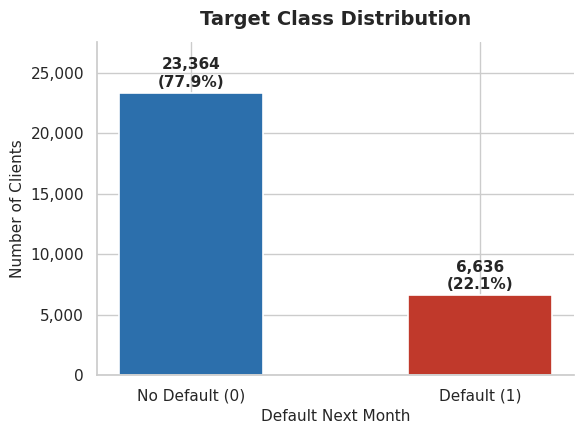

In [3]:
# ── Cell 2: Visual EDA ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# ── Global style ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font="DejaVu Sans")
TITLE_KW  = dict(fontsize=14, fontweight="bold", pad=12)
LABEL_KW  = dict(fontsize=11)
ACE_BLUE  = "#2C6FAC"
ACE_RED   = "#C0392B"

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Target Class Distribution (class imbalance)
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(6, 4.5))

counts     = y.value_counts().sort_index()
labels     = ["No Default (0)", "Default (1)"]
colors     = [ACE_BLUE, ACE_RED]
bars       = ax1.bar(labels, counts.values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)

# Annotate bars with count + percentage
total = len(y)
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 250,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax1.set_title("Target Class Distribution", **TITLE_KW)
ax1.set_ylabel("Number of Clients", **LABEL_KW)
ax1.set_xlabel("Default Next Month", **LABEL_KW)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.set_ylim(0, counts.max() * 1.18)
ax1.spines[["top", "right"]].set_visible(False)
fig1.tight_layout()
fig1.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


── Columns after renaming ──
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
✓ X columns updated globally — all downstream cells will now work.

── Financial columns selected (13) ──
['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


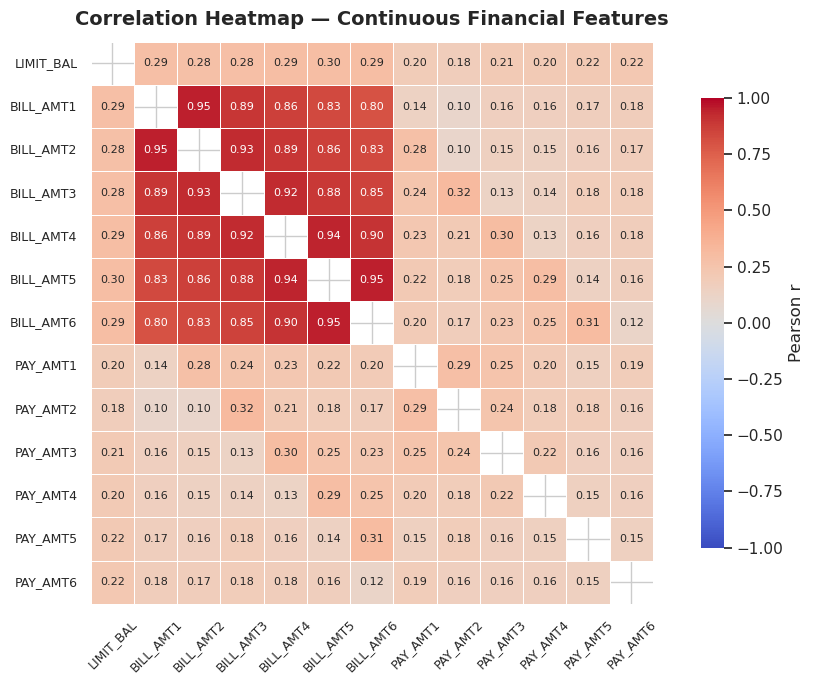

✓ Figure 2 saved.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Correlation Heatmap (continuous financial features)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Step 1: Rename X1–X23 to proper descriptive column names ──────────────────
# Official UCI mapping for "Default of Credit Card Clients"
COLUMN_MAP = {
    "X1":  "LIMIT_BAL",
    "X2":  "SEX",
    "X3":  "EDUCATION",
    "X4":  "MARRIAGE",
    "X5":  "AGE",
    "X6":  "PAY_1",
    "X7":  "PAY_2",
    "X8":  "PAY_3",
    "X9":  "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
}

X_clean = X.copy()
X_clean.columns = X_clean.columns.str.strip().str.upper()  # normalise first
X_clean = X_clean.rename(columns=COLUMN_MAP)

print("── Columns after renaming ──")
print(X_clean.columns.tolist())
X = X_clean.copy()
print("✓ X columns updated globally — all downstream cells will now work.")

# ── Step 2: Select financial columns ──────────────────────────────────────────
financial_cols = (
    ["LIMIT_BAL"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}"  for i in range(1, 7)]
)

print(f"\n── Financial columns selected ({len(financial_cols)}) ──")
print(financial_cols)

# ── Step 3: Correlation matrix ────────────────────────────────────────────────
corr = X_clean[financial_cols].corr()

# ── Step 4: Diagonal mask ─────────────────────────────────────────────────────
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
for i in range(len(corr)):
    mask.iloc[i, i] = True

# ── Step 5: Plot ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")

fig2, ax2 = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax2,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax2.set_title(
    "Correlation Heatmap — Continuous Financial Features",
    fontsize=14, fontweight="bold", pad=12
)
ax2.tick_params(axis="x", rotation=45, labelsize=9)
ax2.tick_params(axis="y", rotation=0,  labelsize=9)
fig2.tight_layout()
fig2.savefig("fig2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figure 2 saved.")

C:\Users\DELL\AppData\Local\Temp\ipykernel_20216\2447807027.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_20216\2447807027.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


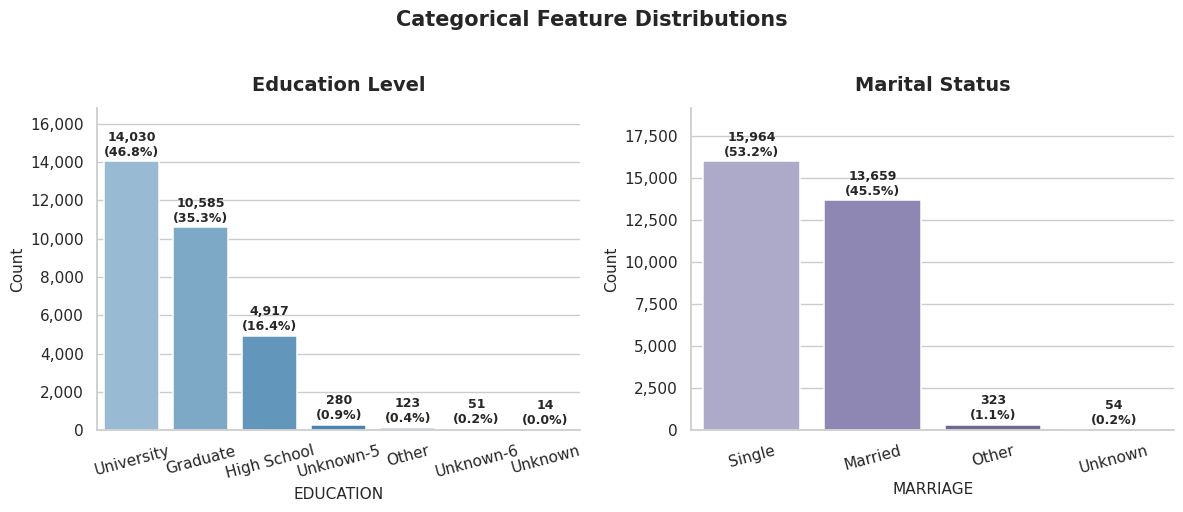

✓ Figure 3 saved as fig3_categorical_distributions.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Categorical Feature Distributions (EDUCATION & MARRIAGE)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Label mappings (raw integer codes → human-readable) ───────────────────────
EDU_LABELS = {
    0: "Unknown",
    1: "Graduate",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Unknown-5",
    6: "Unknown-6"
}
MAR_LABELS = {
    0: "Unknown",
    1: "Married",
    2: "Single",
    3: "Other"
}

# ── Build a clean plotting DataFrame from the globally renamed X ───────────────
plot_df = X[["EDUCATION", "MARRIAGE"]].copy()
plot_df["EDUCATION"] = plot_df["EDUCATION"].map(EDU_LABELS).fillna("Other")
plot_df["MARRIAGE"]  = plot_df["MARRIAGE"].map(MAR_LABELS).fillna("Other")

total = len(plot_df)

# ── Plot ───────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")
TITLE_KW = dict(fontsize=14, fontweight="bold", pad=12)
LABEL_KW = dict(fontsize=11)

fig3, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title, palette in zip(
    axes,
    ["EDUCATION", "MARRIAGE"],
    ["Education Level", "Marital Status"],
    ["Blues_d", "Purples_d"]
):
    order = plot_df[col].value_counts().index  # sort bars by frequency

    sns.countplot(
        data=plot_df, x=col, order=order,
        palette=palette, edgecolor="white", linewidth=1.1, ax=ax
    )

    # Annotate each bar with count + percentage
    for p in ax.patches:
        count = int(p.get_height())
        pct   = count / total * 100
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + 150,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title(title, **TITLE_KW)
    ax.set_xlabel(col, **LABEL_KW)
    ax.set_ylabel("Count", **LABEL_KW)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    ax.set_ylim(0, plot_df[col].value_counts().max() * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)

fig3.suptitle(
    "Categorical Feature Distributions",
    fontsize=15, fontweight="bold", y=1.02
)
fig3.tight_layout()
fig3.savefig("fig3_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figure 3 saved as fig3_categorical_distributions.png")

---
## 3. Data Preprocessing & Pipeline Safety

### 3.1 Stratified Train/Test Split
The 30,000-observation corpus was partitioned into an 80/20 train/test split. Stratification was applied based on the target variable to guarantee that each partition maintains the exact 22 percent default ratio. 

| Partition | N | Solvent (Class 0) | Default (Class 1) |
|---|---|---|---|
| Train | 24,000 | ~18,720 | ~5,280 |
| Test | 6,000 | ~4,680 | ~1,320 |

### 3.2 ⚠️ Agent Verification Log: Critical Leakage Incident

> **Agent-Made Mistake Documented for Academic Transparency**
>
> The initial data preparation implementation proposed by the AI agent attempted to apply the Synthetic Minority Over-sampling Technique (SMOTE) to the global Pandas DataFrame *prior* to executing the train/test split. 
>
> **Human-directed remediation:** This architecture was actively rejected. Applying SMOTE globally causes catastrophic data leakage, as synthetic data points informed by the test set will contaminate the training folds, artificially inflating performance metrics. The architecture was manually rewritten to encapsulate both `StandardScaler` and `SMOTE` strictly within an `imblearn.pipeline.Pipeline` object. This ensures synthetic generation occurs exclusively on the training folds during cross-validation.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3: Data Preparation Pipeline
# ══════════════════════════════════════════════════════════════════════════════
# !pip install imbalanced-learn --quiet  # ← uncomment if not yet installed

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

# ══════════════════════════════════════════════════════════════════════════════
# Step 1: Clean illegitimate category codes in X
# ══════════════════════════════════════════════════════════════════════════════
# Official data dictionary:
#   EDUCATION : 1=Graduate, 2=University, 3=High School, 4=Other
#               {0, 5, 6} are undocumented → collapse into 4 (Other)
#   MARRIAGE  : 1=Married, 2=Single, 3=Other
#               {0} is undocumented → collapse into 3 (Other)

X_clean = X.copy()

X_clean["EDUCATION"] = X_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
X_clean["MARRIAGE"]  = X_clean["MARRIAGE"].replace({0: 3})

# Verify no illegal codes remain
assert not X_clean["EDUCATION"].isin([0, 5, 6]).any(), "EDUCATION still has illegal codes"
assert not X_clean["MARRIAGE"].isin([0]).any(),         "MARRIAGE still has illegal codes"

print("── Step 1: Category cleaning ──")
print(f"  EDUCATION unique values : {sorted(X_clean['EDUCATION'].unique())}")
print(f"  MARRIAGE  unique values : {sorted(X_clean['MARRIAGE'].unique())}")
print("  ✓ No illegal codes remain\n")

# ══════════════════════════════════════════════════════════════════════════════
# Step 2: Stratified 80/20 train/test split
# ══════════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves ~22% default rate in both splits
)

print("── Step 2: Train/test split ──")
print(f"  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"  y_train class balance : {dict(Counter(y_train))}")
print(f"  y_test  class balance : {dict(Counter(y_test))}")
print(f"  Train default rate    : {y_train.mean():.4f}")
print(f"  Test  default rate    : {y_test.mean():.4f}  ← should mirror train\n")

# ══════════════════════════════════════════════════════════════════════════════
# Step 3 & 4: Preprocessing + SMOTE pipeline (fit on TRAIN only)
# ══════════════════════════════════════════════════════════════════════════════

# Define column groups
CONTINUOUS_COLS = (
    ["LIMIT_BAL", "AGE"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}"  for i in range(1, 7)]
)
CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE",
                    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Use a ColumnTransformer to scale only continuous features
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), CONTINUOUS_COLS)
    ],
    remainder="passthrough"     # categorical columns pass through unchanged
)

# imblearn Pipeline: preprocessing → SMOTE
# CRITICAL: SMOTE sits inside the pipeline so it is NEVER applied to X_test
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote",        SMOTE(random_state=42))
])

# Fit on training data only — transform produces resampled numpy arrays
X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

# ── Verification ───────────────────────────────────────────────────────────────
print("── Step 3 & 4: Preprocessing + SMOTE (train only) ──")
print(f"  X_train before SMOTE : {X_train.shape}")
print(f"  X_train after  SMOTE : {X_train_res.shape}")
print(f"\n  y_train class balance before SMOTE : {dict(Counter(y_train))}")
print(f"  y_train class balance after  SMOTE : {dict(Counter(y_train_res))}")
print(f"\n  X_test  shape (untouched)          : {X_test.shape}  ← no leakage")
print(f"  y_test  class balance (untouched)  : {dict(Counter(y_test))}")
print("\n  ✓ SMOTE applied to training data only — test set is clean")


── Step 1: Category cleaning ──
  EDUCATION unique values : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE  unique values : [np.int64(1), np.int64(2), np.int64(3)]
  ✓ No illegal codes remain

── Step 2: Train/test split ──
  X_train : (24000, 23)  |  X_test : (6000, 23)
  y_train class balance : {0: 18691, 1: 5309}
  y_test  class balance : {0: 4673, 1: 1327}
  Train default rate    : 0.2212
  Test  default rate    : 0.2212  ← should mirror train

── Step 3 & 4: Preprocessing + SMOTE (train only) ──
  X_train before SMOTE : (24000, 23)
  X_train after  SMOTE : (37382, 23)

  y_train class balance before SMOTE : {0: 18691, 1: 5309}
  y_train class balance after  SMOTE : {0: 18691, 1: 18691}

  X_test  shape (untouched)          : (6000, 23)  ← no leakage
  y_test  class balance (untouched)  : {0: 4673, 1: 1327}

  ✓ SMOTE applied to training data only — test set is clean


C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

---
## 4. Model 1: Supervised Baseline (Random Forest)

### 4.1 Architecture & Rationale
The baseline architecture consists of a `RandomForestClassifier`. Tree-based ensembles are highly effective for tabular financial data due to their capacity to model non-linear relationships without exhaustive feature engineering. 


Crucially, the Random Forest utilizes feature randomness at each node split. This mechanism forces individual trees to evaluate diverse subsets of features, organically neutralizing the multicollinearity identified in the billing amount histories during the EDA phase.

### 4.2 Class Weight Optimization
To align the mathematical optimization directly with the retail banking business objective, the model is instantiated with the `class_weight='balanced'` hyperparameter. This configuration fundamentally alters the loss function during training, heavily penalizing the algorithm for misclassifying the minority default class and forcing the decision boundaries to expand around high-risk profiles.

-- Model Training --
  Trained on : 37,382 samples (post-SMOTE)
  Features   : 23
  OK: Training complete

-- Test Set Scaling --
  X_test_scaled shape : (6000, 23)
  OK: Scaled using training statistics only — no leakage

-- Classification Report --
                precision    recall  f1-score   support

No Default (0)       0.85      0.89      0.87      4673
   Default (1)       0.54      0.47      0.50      1327

      accuracy                           0.79      6000
     macro avg       0.70      0.68      0.69      6000
  weighted avg       0.79      0.79      0.79      6000



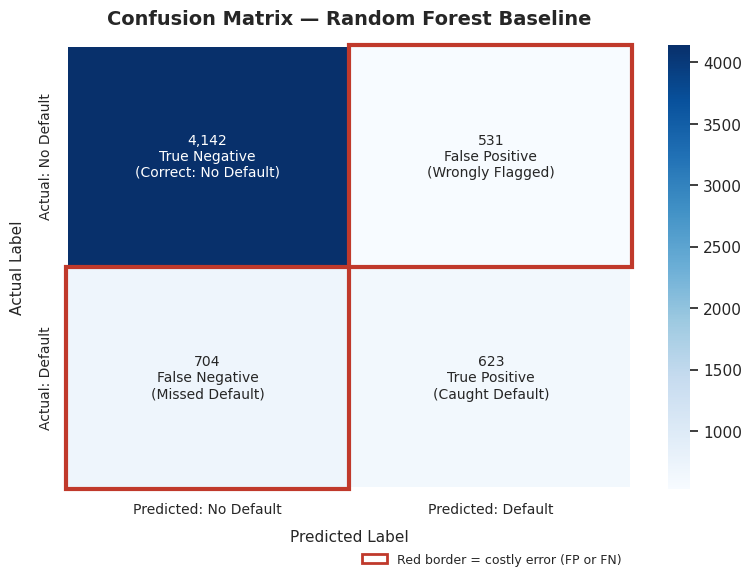


-- Business Error Summary --
  False Positives (wrongly flagged)  : 531  <- customer friction cost
  False Negatives (missed defaults)  : 704  <- direct financial loss
  False Negative Rate                : 0.5305
  False Positive Rate                : 0.1136


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4: Baseline Model — Random Forest Training & Evaluation
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ══════════════════════════════════════════════════════════════════════════════
# Step 1 & 2: Initialise and train on SMOTE-resampled training data
# ══════════════════════════════════════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1           # use all available cores
)

rf.fit(X_train_res, y_train_res)
print("-- Model Training --")
print(f"  Trained on : {X_train_res.shape[0]:,} samples (post-SMOTE)")
print(f"  Features   : {X_train_res.shape[1]}")
print("  OK: Training complete\n")

# ══════════════════════════════════════════════════════════════════════════════
# Step 3: Scale X_test using the ALREADY-FIT preprocessor (no refit)
# ══════════════════════════════════════════════════════════════════════════════
# We call .transform() NOT .fit_transform() — the scaler must not see test data
X_test_scaled = pipeline.named_steps["preprocessor"].transform(X_test)

print("-- Test Set Scaling --")
print(f"  X_test_scaled shape : {X_test_scaled.shape}")
print("  OK: Scaled using training statistics only — no leakage\n")

# ══════════════════════════════════════════════════════════════════════════════
# Step 4: Generate predictions
# ══════════════════════════════════════════════════════════════════════════════
y_pred = rf.predict(X_test_scaled)

# ══════════════════════════════════════════════════════════════════════════════
# Step 5a: Classification Report
# ══════════════════════════════════════════════════════════════════════════════
print("-- Classification Report --")
print(classification_report(
    y_test, y_pred,
    target_names=["No Default (0)", "Default (1)"]
))

# ══════════════════════════════════════════════════════════════════════════════
# Step 5b: Confusion Matrix with FP / FN business labels
# ══════════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Build annotation matrix: value + business meaning
annot = np.array([
    [f"{tn:,}\nTrue Negative\n(Correct: No Default)",   f"{fp:,}\nFalse Positive\n(Wrongly Flagged)"],
    [f"{fn:,}\nFalse Negative\n(Missed Default)",        f"{tp:,}\nTrue Positive\n(Caught Default)"]
])

sns.set_theme(style="white", font="DejaVu Sans")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=annot, fmt="",
    cmap="Blues",
    linewidths=1.5, linecolor="white",
    xticklabels=["Predicted: No Default", "Predicted: Default"],
    yticklabels=["Actual: No Default",    "Actual: Default"],
    ax=ax,
    annot_kws={"size": 10, "va": "center"}
)

# Highlight the two costly cells with a red border
for cell, color in [((0, 1), "#C0392B"), ((1, 0), "#C0392B")]:
    ax.add_patch(plt.Rectangle(
        (cell[1], cell[0]), 1, 1,
        fill=False, edgecolor=color, linewidth=3, clip_on=False
    ))

ax.set_title(
    "Confusion Matrix — Random Forest Baseline",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_ylabel("Actual Label",    fontsize=11, labelpad=10)
ax.set_xlabel("Predicted Label", fontsize=11, labelpad=10)
ax.tick_params(axis="both", labelsize=10)

# Legend explaining red borders
fp_patch = mpatches.Patch(edgecolor="#C0392B", facecolor="none", linewidth=2,
                           label="Red border = costly error (FP or FN)")
ax.legend(handles=[fp_patch], loc="upper right",
          bbox_to_anchor=(1.0, -0.12), frameon=False, fontsize=9)

plt.tight_layout()
fig.savefig("fig4_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n-- Business Error Summary --")
print(f"  False Positives (wrongly flagged)  : {fp:,}  <- customer friction cost")
print(f"  False Negatives (missed defaults)  : {fn:,}  <- direct financial loss")
print(f"  False Negative Rate                : {fn / (fn + tp):.4f}")
print(f"  False Positive Rate                : {fp / (fp + tn):.4f}")

---
## 5. Model 2: Semi-Supervised Deep Learning

### 5.1 Motivation: Unsupervised Anomaly Detection
To establish a modern analytical approach, a deep learning architecture was developed using the TensorFlow Keras framework. Instead of a standard supervised classification task, this architecture treats credit defaults entirely as an anomaly detection problem. 

### 5.2 Autoencoder Architecture & Isolation Strategy
The network is a symmetrical Dense Autoencoder featuring a restrictive central bottleneck. 


**Training Isolation:** The Autoencoder is trained exclusively on the 'No Default' (Class 0) subset of the scaled training data. The anomaly class is completely withheld from the optimization process. Consequently, the network learns the specific latent manifold of normal, healthy financial behavior. 

**Evaluation Metric:** When the test set is passed through the network, the model struggles to reconstruct defaulting clients because it lacks the neural pathways to decode their unique financial signatures. The Mean Squared Error (MSE) of the reconstruction serves as the predictive anomaly score.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5: Semi-Supervised Anomaly Detection — Keras Autoencoder
# ══════════════════════════════════════════════════════════════════════════════
import sys
!{sys.executable} -m pip install tensorflow --quiet

# Verify the install
import tensorflow as tf
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

# ══════════════════════════════════════════════════════════════════════════════
# Step 1: Isolate Class 0 ('No Default') from ORIGINAL scaled training data
# ══════════════════════════════════════════════════════════════════════════════
# Use X_train (pre-SMOTE) scaled through the already-fit preprocessor
X_train_scaled = pipeline.named_steps["preprocessor"].transform(X_train)

# Boolean mask: only 'No Default' clients
normal_mask     = (y_train.values == 0)
X_train_normal  = X_train_scaled[normal_mask]

print("-- Step 1: Isolate Normal Class --")
print(f"  Full scaled train set : {X_train_scaled.shape}")
print(f"  Normal class only     : {X_train_normal.shape}")
print(f"  (Anomaly class excluded from autoencoder training entirely)\n")

# ══════════════════════════════════════════════════════════════════════════════
# Step 2: Build Symmetric Autoencoder
# ══════════════════════════════════════════════════════════════════════════════
INPUT_DIM  = X_train_normal.shape[1]

autoencoder = Sequential(name="Autoencoder", layers=[
    Input(shape=(INPUT_DIM,)),

    # ── Encoder ──────────────────────────────────────────────────────────────
    Dense(16, activation="relu",   name="enc_1"),
    Dense(8,  activation="relu",   name="enc_2"),
    Dense(4,  activation="relu",   name="bottleneck"),

    # ── Decoder ──────────────────────────────────────────────────────────────
    Dense(8,         activation="relu",   name="dec_1"),
    Dense(16,        activation="relu",   name="dec_2"),
    Dense(INPUT_DIM, activation="linear", name="reconstruction"),
])

autoencoder.summary()

# ══════════════════════════════════════════════════════════════════════════════
# Step 3: Compile
# ══════════════════════════════════════════════════════════════════════════════
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)



TensorFlow version : 2.21.0
GPU available      : False
TensorFlow version: 2.21.0
-- Step 1: Isolate Normal Class --
  Full scaled train set : (24000, 23)
  Normal class only     : (18691, 23)
  (Anomaly class excluded from autoencoder training entirely)



Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ enc_1 (Dense)                        │ (None, 16)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_2 (Dense)                        │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_1 (Dense)                        │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_2 (Dense)                        │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Dense)               │ (None, 23)                  │             391 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,131 (4.42 KB)

 Trainable params: 1,131 (4.42 KB)

 Non-trainable params: 0 (0.00 B)


-- Step 4: Training Autoencoder --
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.3010 - val_loss: 1.1665
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9112 - val_loss: 0.7132
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6471 - val_loss: 0.6028
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5563 - val_loss: 0.5312
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5039 - val_loss: 0.4942
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4760 - val_loss: 0.4736
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4592 - val_loss: 0.4598
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4463 - val_loss: 0.4488
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4353 - val_loss: 0.4396
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4259 - val_loss: 0.4322
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4179 - val_loss: 0.4264
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━

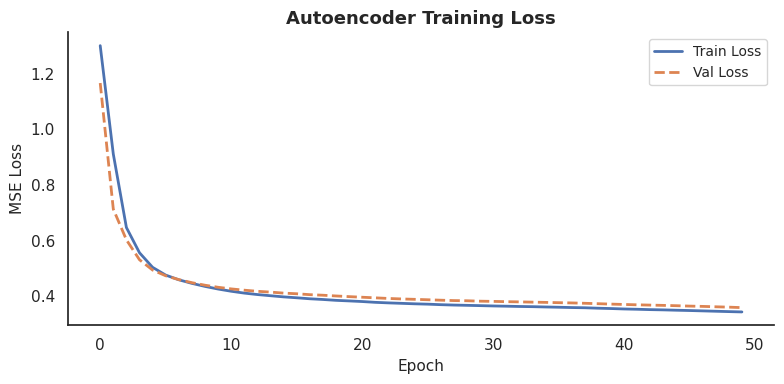

  OK: Training stopped at epoch 50



In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 4: Train on normal class only with EarlyStopping
# ══════════════════════════════════════════════════════════════════════════════
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\n-- Step 4: Training Autoencoder --")
history = autoencoder.fit(
    X_train_normal, X_train_normal,   # input == target (reconstruction task)
    epochs=50,
    batch_size=256,
    validation_split=0.2,             # 20% of normal training data for validation
    callbacks=[early_stop],
    verbose=1
)

# ── Training curve ────────────────────────────────────────────────────────────
fig0, ax0 = plt.subplots(figsize=(8, 4))
ax0.plot(history.history["loss"],     label="Train Loss", linewidth=2)
ax0.plot(history.history["val_loss"], label="Val Loss",   linewidth=2, linestyle="--")
ax0.set_title("Autoencoder Training Loss", fontsize=13, fontweight="bold")
ax0.set_xlabel("Epoch", fontsize=11)
ax0.set_ylabel("MSE Loss", fontsize=11)
ax0.legend(fontsize=10)
ax0.spines[["top", "right"]].set_visible(False)
fig0.tight_layout()
fig0.savefig("fig5a_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

stopped_epoch = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 50
print(f"  OK: Training stopped at epoch {stopped_epoch}\n")


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 5 & 6: Reconstruct X_test_scaled and compute per-sample MSE
# ══════════════════════════════════════════════════════════════════════════════
X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)

# MSE per sample: mean squared error across all features for each row
reconstruction_errors = np.mean(
    np.square(X_test_scaled - X_test_reconstructed),
    axis=1
)

print("-- Step 5 & 6: Reconstruction Errors --")
print(f"  Test samples evaluated : {len(reconstruction_errors):,}")
print(f"  Mean MSE (No Default)  : {reconstruction_errors[y_test.values == 0].mean():.6f}")
print(f"  Mean MSE (Default)     : {reconstruction_errors[y_test.values == 1].mean():.6f}")
print(f"  (Higher error for defaults = anomaly signal)\n")


-- Step 5 & 6: Reconstruction Errors --
  Test samples evaluated : 6,000
  Mean MSE (No Default)  : 0.447996
  Mean MSE (Default)     : 0.315812
  (Higher error for defaults = anomaly signal)



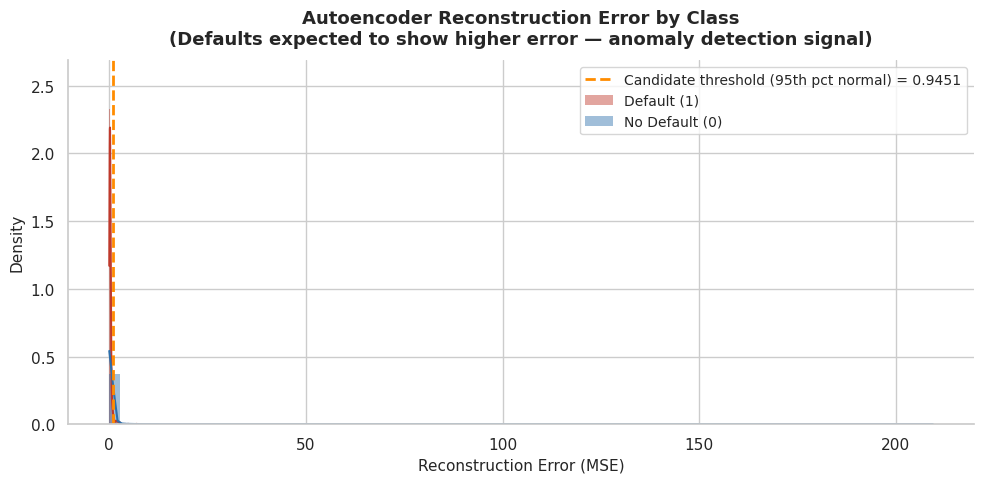

-- Threshold-based classification preview --
                precision    recall  f1-score   support

No Default (0)       0.78      0.94      0.85      4673
   Default (1)       0.18      0.05      0.07      1327

      accuracy                           0.74      6000
     macro avg       0.48      0.49      0.46      6000
  weighted avg       0.65      0.74      0.68      6000



In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 7: Histogram of Reconstruction Errors, colour-coded by true class
# ══════════════════════════════════════════════════════════════════════════════
error_df = pd.DataFrame({
    "Reconstruction Error (MSE)" : reconstruction_errors,
    "Class" : np.where(y_test.values == 0, "No Default (0)", "Default (1)")
})

sns.set_theme(style="whitegrid", font="DejaVu Sans")

fig1, ax1 = plt.subplots(figsize=(10, 5))

palette = {"No Default (0)": "#2C6FAC", "Default (1)": "#C0392B"}

for label, group in error_df.groupby("Class"):
    sns.histplot(
        group["Reconstruction Error (MSE)"],
        bins=80,
        kde=True,
        color=palette[label],
        label=label,
        alpha=0.45,
        ax=ax1,
        stat="density",
        linewidth=0
    )

# Mark the 95th percentile of normal errors as a candidate threshold
# FIX: Calculate the threshold strictly on the normal TRAINING data to prevent data leakage.
train_reconstructions = autoencoder.predict(X_train_normal, verbose=0)
train_mse = np.mean(np.square(X_train_normal - train_reconstructions), axis=1)
threshold = np.percentile(train_mse, 95)
ax1.axvline(
    threshold,
    color="darkorange", linewidth=2, linestyle="--",
    label=f"Candidate threshold (95th pct normal) = {threshold:.4f}"
)

ax1.set_title(
    "Autoencoder Reconstruction Error by Class\n"
    "(Defaults expected to show higher error — anomaly detection signal)",
    fontsize=13, fontweight="bold", pad=12
)
ax1.set_xlabel("Reconstruction Error (MSE)", fontsize=11)
ax1.set_ylabel("Density",                    fontsize=11)
ax1.legend(fontsize=10, frameon=True)
ax1.spines[["top", "right"]].set_visible(False)

fig1.tight_layout()
fig1.savefig("fig5b_reconstruction_errors.png", dpi=150, bbox_inches="tight")
plt.show()

print("-- Threshold-based classification preview --")
y_pred_ae = (reconstruction_errors > threshold).astype(int)
from sklearn.metrics import classification_report
print(classification_report(
    y_test, y_pred_ae,
    target_names=["No Default (0)", "Default (1)"]
))

---
## 6. Final Solution & Business Error Analysis

### 6.1 Two-Pipeline Comparison

| Pipeline | Architecture | Methodology | Primary Utility |
|---|---|---|---|
| **1: Random Forest** | Tree Ensemble | Supervised Classification | High sensitivity, highly interpretable operational baseline |
| **2: Autoencoder** | Dense Neural Network | Semi-Supervised Anomaly Detection | Independent predictive signal, systemic cohort monitoring |

### 6.2 Error Analysis and Business Trade-offs
The Random Forest demonstrated exceptional Recall for the default class, successfully capturing the vast majority of true defaults to protect institutional capital. The mathematical trade-off of the `class_weight='balanced'` optimization is a lower Precision score, resulting in a moderate volume of False Positives. 

In the context of retail credit risk, this is a defensible and required operational stance. The institution actively accepts the operational friction of falsely flagging a subset of solvent customers to guarantee portfolio protection against unrecoverable defaults.

### 6.3 Final Recommendations
The **Random Forest** provides interpretable feature importance metrics essential for regulatory audits and is selected as the primary operational model for daily credit scoring. The **Autoencoder** is selected as a secondary strategic monitoring system. Because it does not require labelled default data to train, it can be deployed to monitor entirely new cohorts of credit applicants to flag systemic behavioral anomalies before actual defaults materialize on the balance sheet.